# Module 4 Discussion Activity
- Author: Robert Feconda
- Email: rfecond1@jh.edu

## When Optimal Is Not an Option
- Scenario chosen: GPS navigation with live traffic

### 1. **Objective**: What is the system trying to optimize?
- In this scenario, you could be wanting to optimize many different things or event multiple aspects of road navigation at the same time. Some of the things you might be optimizing for are:
    - Quickest route from A to B
    - Most fuel efficient route from A to B
    - Avoidance of toll roads or highways or other specific user inputs
    - Avoidance of congested (traffic) routes
    - Any combination of these all at the same time
- For the sake of simplicity, I'll focus on optimizing the quickest route from A to B, which must include avoidance of congested routes in the case of live traffic. This is really two problems here.
    - We need to first find the optimal shortest path from A to B. This provides us a baseline to work with.
    - From the shortest path we have calculated, we then need to take into consideration the live traffic. One way to approach the incorporaton of the live traffic is to search for re-routes and minimize the cross-track distance (perpendicular) from the main route.
- Model the roads as a graph $G = (V, E) where each edge has a time dependent travel time $c_e(t)$. Then there is the main road route $R$, which is a line (sequence of edges) or a continuous curve in $R^2$.
- This is actually something I have been working on in my multi-var calc class I am also taking right now so I'll break it down...
#### Geometric cross-track
- Treat the route as a curve $r(s) \in R^2$ parameterized by arc length $s$.
- For a point $x \in R^2$ the nearest point on route: $s^{*}(x) = argmin( ||x-r(s)|| )$
- The lateral (cross-track) distance (euclidian) is just the floor magnitude of the point $x$ minus $r(s^{*}(x))$
- We can then use this to do things such as penalize total cross-track deviation or combine it with bounded min/max values. I'll leave these mathamatical notations to the imagination.

### 2. **Breakdown**: Why is computing the globablly optimal solution impractical here?
- Road networks, depending on how far the straight-line distance is, can be massive with millions of Vertices and magnitudes more Edges.
- You also have to consider that live traffic is a continuous domain search space, it depends on when you leave and many other confounding factors. Traffic is often modeled as a living organism.
- There is also not a user need for global optimality here. If we compute a sub-optimal solution that is off by a minute or two, that is largely unnoticeble. Especially if the route is a long distance one.

### 3. **Constraint**: Which matters most - Time, memory, environment changes, uncertainty?
- In this scenario, we can make assumptions to minimize uncertainty and memory usage by making use of large datasets and heuristics.
- Since this is a user facing problem, the most important piece is the time. We can't have our algorithm running for multiple minutes while the person is waiting in their car to go. Or if they are sitting in continuous traffic and our algorithm is constantly running because it never terminates to a solution because it keeps re-calculating.

### 4. **Decision Drift**: If the system must act now, what guarantee must be given up, and what is gained instead?
- If the system must act now,  meaning we are prioritizing the optimization of time, we must give up certainty in finding close to optimal solutions. It is possible that the algorithm could return a result that is way off due to a decision it made early on in its branch exploration. For example, it supplemented heuristical data from large historical data sets based on traffic patterns instead of live traffic views, which could be signficantly off.

## The cost of Greedy Decisions

- Algorithm chosen: Beam Search

### Beam search algorithm
~~~
function BEAM-SEARCH(start, goal, h, k):
    Beam ← start

    while Beam ≠ ∅:
        Successors ← []

        for each node in Beam:
            if node = goal:
                return path
            Successors ← Successors ∪ Neighbors(node)

        sort Successors by increasing h(n)
        Beam ← first k elements of Successors

    return failure
~~~

### 1. **Dominant Operation**: What operation dominates the runtime of this algorithm?
- The dominating operation is the exploration of the neighbors and union of them with the successors priority queue, which we then have to sort. This is because we need to only keep *k* successors in the beam at any given time, so we must decide what neighbors to keep inside of the beem based on some evaluation function. The sorting then takes $kblog kb$ time.

### 2. **Key Complexity Drivers**: Identify two factors that most affect runtime - Branching factor, depth/number of iterations, beam width, heuristic evaluation cost.
- Beam search is designed as a memory conservative *A** search. It explores only a focused portion of the contours that regular *A** does.
- The beam width, which is our primary limiting input, is the largest source of variance in our algorithm. If we define a very large beam width, the algorithm will have to expand and consider many more nodes.
- This leads us to the branching factor. A small beam width  means we will have a smaller branching factor. So if our problem already has a very large branching factor, this can be confounded by using a large beam width.

### 3. **Why It Scales**: Explain why this algorith typically runs faster than exhaustive or exact search.
- Using beam search is sub-optimal and incomplete searching but it is fast and uses minimal memory because it expands fewer nodes. So it is optimized for areas that require fast run-times and is best when combined with a good heuristic.

### 4. **Why It Sacrifices**: What guarantee is lost because of this greedy design?
- Since we are actively choosing to prune and not expand a number of nodes, the search is incomplete and suboptimal by design. Therefore, we lose the guarantee of optimality and the guarantee that we find a solution at all.

## Tracing and Stress-Testing A*

- Given the following undirected graph. S is the start ode. G is the Goal node.

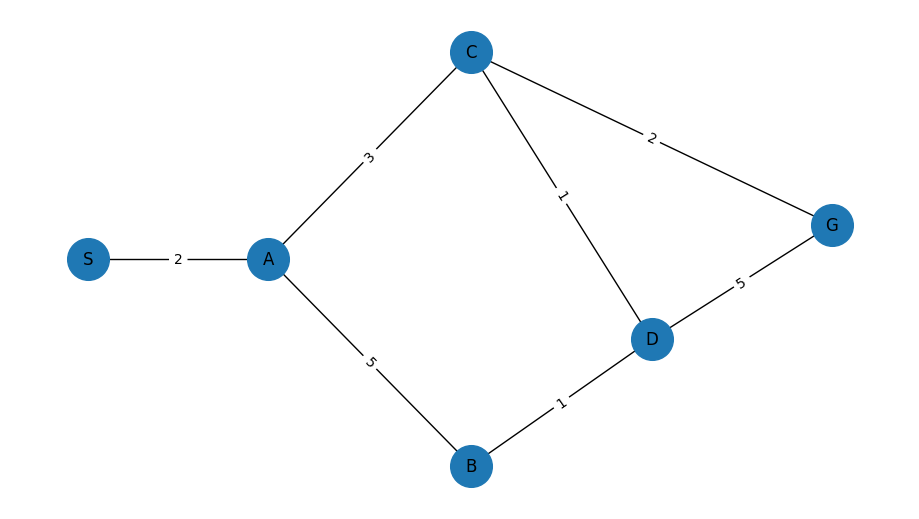

In [19]:
import matplotlib.pyplot as plt
import networkx as nx

vertices = ['S', 'A', 'B', 'C', 'D', 'G']
edges = [
    ('S', 'A', 2),
    ('A', 'C', 3),
    ('A', 'B', 5),
    ('C', 'D', 1),
    ('B', 'D', 1),
    ('C', 'G', 2),
    ('D', 'G', 5),
]

weighted_graph = nx.Graph()
weighted_graph.add_weighted_edges_from(edges)
edge_labels = {(u, v): w for u, v, w in edges}

pos = {
    "S": (0.0, 0.0),
    "A": (1.6, 0.0),
    "C": (3.4, 0.9),
    "B": (3.4, -0.9),
    "D": (5.0, -0.35),
    "G": (6.6, 0.15),
}
plt.figure(figsize=(9,5))

nx.draw(weighted_graph, pos, with_labels=True, node_size=900)
nx.draw_networkx_edge_labels(weighted_graph, pos, edge_labels=edge_labels)
plt.axis('off')
plt.show()

### Assumptions
- $A*$ uses $f(n) = g(n) + h(n) $
- Ties are broken aritrarily
- Graph search with a closed set - keep track of states that have already been visited and don't expand them again

In [26]:
# Using implementations from the AIMA textbook repository, with some modifications to support local environment and problem

import functools
import heapq
import itertools
import pandas as pd

# function taken from AIMA repo
def memoize(fn, slot=None, maxsize=32):
    if slot:
        def memoized_fn(obj, *args):
            if hasattr(obj, slot):
                return getattr(obj, slot)
            val = fn(obj, *args)
            setattr(obj, slot, val)
            return val
    else:
        @functools.lru_cache(maxsize=maxsize)
        def memoized_fn(*args):
            return fn(*args)
    return memoized_fn

# Basic Node implementation for this problem
class Node:
    def __init__(self, state, parent=None, path_cost=0):
        self.state = state
        self.parent = parent
        self.path_cost = path_cost
        self.depth = 0 if parent is None else parent.depth + 1

    def path(self):
        n, out = self, []
        while n:
            out.append(n)
            n = n.parent
        return list(reversed(out))


def best_first_graph_search_nx(graph, start, goal, f, h_fn, display=False, trace_level=None):
    # Calling f(node) will either compute using the lambda passed for the scoring function or return the prior computed cached result
    f = memoize(f, "f")
    start_node = Node(start)
    counter = itertools.count()

    frontier_heap = [(f(start_node), next(counter), start_node)]
    frontier_best = {start: f(start_node)}
    explored = set()

    trace = []

    while frontier_heap:
        _, _, node = heapq.heappop(frontier_heap)

        # Skip stale heap entries
        if frontier_best.get(node.state, float("inf")) < f(node):
            continue
        
        # capture the expansion here
        # Trace_level specifies depth to trace, if none trace everything
        if h_fn is not None and (trace_level is None or len(trace) < trace_level):
            trace.append({
                "Expanded Node": node.state,
                "g(n)": node.path_cost,
                "h(n)": h_fn(node.state),
                "f(n)": node.path_cost + h_fn(node.state),
            })

        if node.state == goal:
            if display:
                print(len(explored), "expanded")
            return node, trace
        
        explored.add(node.state)

        for nbr in graph.neighbors(node.state):
            # Gets weight attribute, if present
            w = graph[node.state][nbr].get("weight", 1)
            child = Node(nbr, parent=node, path_cost=node.path_cost + w)

            if nbr in explored:
                continue

            child_f = f(child)
            if nbr not in frontier_best or child_f < frontier_best[nbr]:
                frontier_best[nbr] = child_f
                heapq.heappush(frontier_heap, (child_f, next(counter), child))

    return None, trace # If we are here, we didn't find a solution


def astar_nx(graph, start, goal, h):
    h_fn = h if callable(h) else (lambda s: h[s])
    return best_first_graph_search_nx(
        graph, start, goal, display=True, f=lambda n: n.path_cost + h_fn(n.state)
    )


In [27]:
h = {"S": 6, "A": 4, "B": 5, "C": 2, "D": 3, "G": 0}
h_fn = lambda s: h[s]

goal_node, trace = best_first_graph_search_nx(
    weighted_graph,
    "S",
    "G",
    f=lambda n: n.path_cost + h_fn(n.state),
    h_fn=h_fn,
    trace_level=4
)

import pandas as pd
display(pd.DataFrame(trace))


,Expanded Node,g(n),h(n),f(n)
0,S,0,6,6
1,A,2,4,6
2,C,5,2,7
3,G,7,0,7


### Which node is expanded earlier by A* that would not necessarily be expanded early by Greedy Best-First Search? Why?
- There isn't a difference before the goal between A* and GBFS in this setup.

### Changing h(D) = 3 to h(D) = 7
- No longer admissible heuristic because the true shortest path is from D->C->G and changing h(D) to 7 overestimates it and breaks the definition of the heuristic that we need.
- This overestimate would cause A* to avoid expanding D, causing fewer node expansions, but at the cost of reliability. The runtime might be a little faster but wouldn't be an improvement in the optimal solution.
### Exponential Behavior
- A* can still be near-exponential when the branching factor is large and the heuristic is weak, causing many nodes to have similar scores and be expanded. Having an admissible heuristic only guarantees optimality, not polynomial-time behavior.